In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2





In [2]:
# 1. LOAD DATA
crabdata = pd.read_csv('CrabAgePrediction.csv') 

FileNotFoundError: [Errno 2] No such file or directory: 'CrabAgePrediction.csv'

In [ ]:
crabdata.head()

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6


In [ ]:
crabdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3893 entries, 0 to 3892
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             3893 non-null   object 
 1   Length          3893 non-null   float64
 2   Diameter        3893 non-null   float64
 3   Height          3893 non-null   float64
 4   Weight          3893 non-null   float64
 5   Shucked Weight  3893 non-null   float64
 6   Viscera Weight  3893 non-null   float64
 7   Shell Weight    3893 non-null   float64
 8   Age             3893 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 273.9+ KB


In [ ]:
#remove height=0
crabdata = crabdata[crabdata['Height'] > 0]

In [ ]:
print(crabdata.shape)

(3891, 9)


In [ ]:
print(crabdata.duplicated().sum())

0


In [ ]:
# Check for missing values
print("Missing Values per Column:")
print(crabdata.isnull().sum())

Missing Values per Column:
Sex               0
Length            0
Diameter          0
Height            0
Weight            0
Shucked Weight    0
Viscera Weight    0
Shell Weight      0
Age               0
dtype: int64


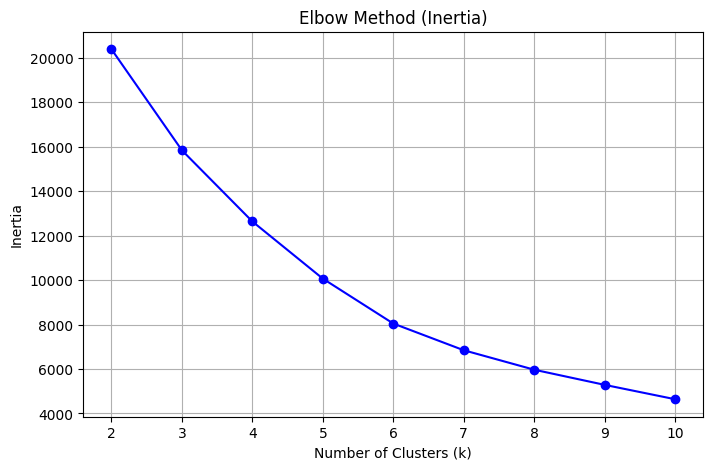

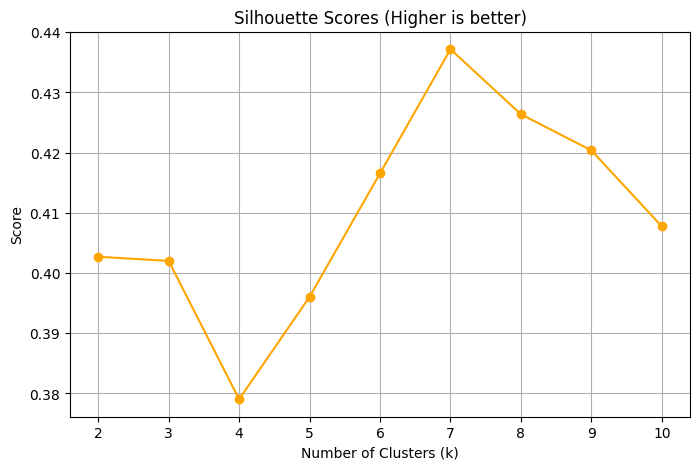

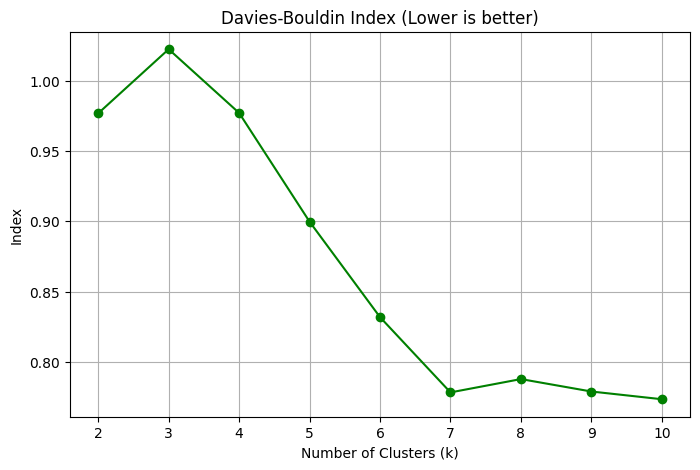

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# 1. Load and Clean Data
df = pd.read_csv('CrabAgePrediction.csv')
df = df[df['Height'] > 0] # Matching your notebook's cleaning step

# 2. Preprocessing
# Encode categorical 'Sex' and drop the target 'Age'
X = pd.get_dummies(df.drop('Age', axis=1), columns=['Sex'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calculate Metrics for a range of k
k_range = range(2, 11)
inertia = []
sil_scores = []
db_indices = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))

# --- GENERATE SEPARATE GRAPHS ---

# Graph 1: Elbow Method (Inertia)
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='blue')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.savefig('elbow_plot.png')
plt.show()

# Graph 2: Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o', color='orange')
plt.title('Silhouette Scores (Higher is better)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.grid(True)
plt.savefig('silhouette_plot.png')
plt.show()

# Graph 3: Davies-Bouldin Index
plt.figure(figsize=(8, 5))
plt.plot(k_range, db_indices, marker='o', color='green')
plt.title('Davies-Bouldin Index (Lower is better)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Index')
plt.grid(True)
plt.savefig('davies_bouldin_plot.png')
plt.show()

cheking for clusters

Optimal clusters based on Silhouette Score: 7


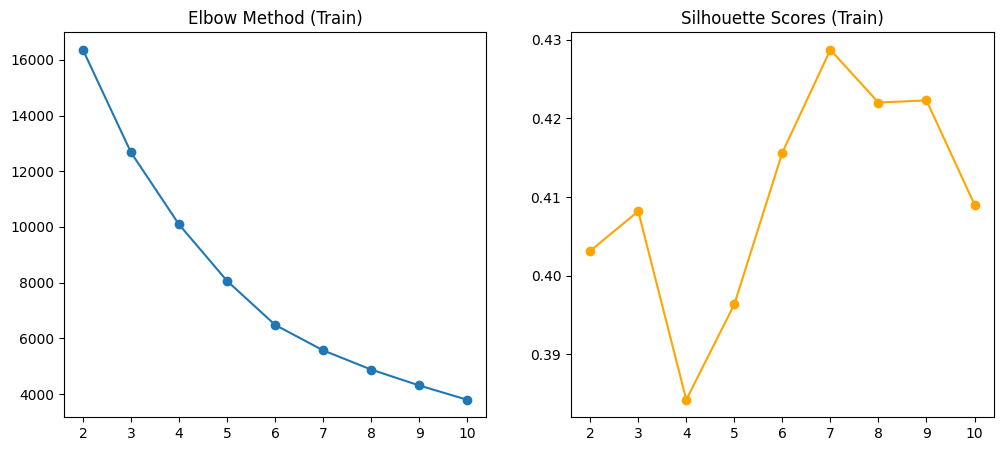

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Load and Basic Cleaning
df = pd.read_csv('CrabAgePrediction.csv')
crabdata = df[df['Height'] > 0] # Using cleaned variable

# 2. Train-Test Split 
# Dropping 'Age' as it is the target
X = pd.get_dummies(crabdata.drop('Age', axis=1), columns=['Sex'])
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# 3. Scaling (Fit on Train, Transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Deciding Optimal Clusters (on Training Data)
k_range = range(2, 11)
inertia = []
sil_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, labels))

# Find optimal K based on max Silhouette Score
optimal_k = k_range[sil_scores.index(max(sil_scores))]
print(f"Optimal clusters based on Silhouette Score: {optimal_k}")

# 5. Visualizing Evaluation Metrics
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method (Train)')

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o', color='orange')
plt.title('Silhouette Scores (Train)')
plt.show()

# 6. Apply to Test Data
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
final_kmeans.fit(X_train_scaled) # Model still learns from Train
test_clusters = final_kmeans.predict(X_test_scaled) # Applied to Test

X_test_with_clusters = X_test.copy()
X_test_with_clusters['Cluster'] = test_clusters

visualisation on test data

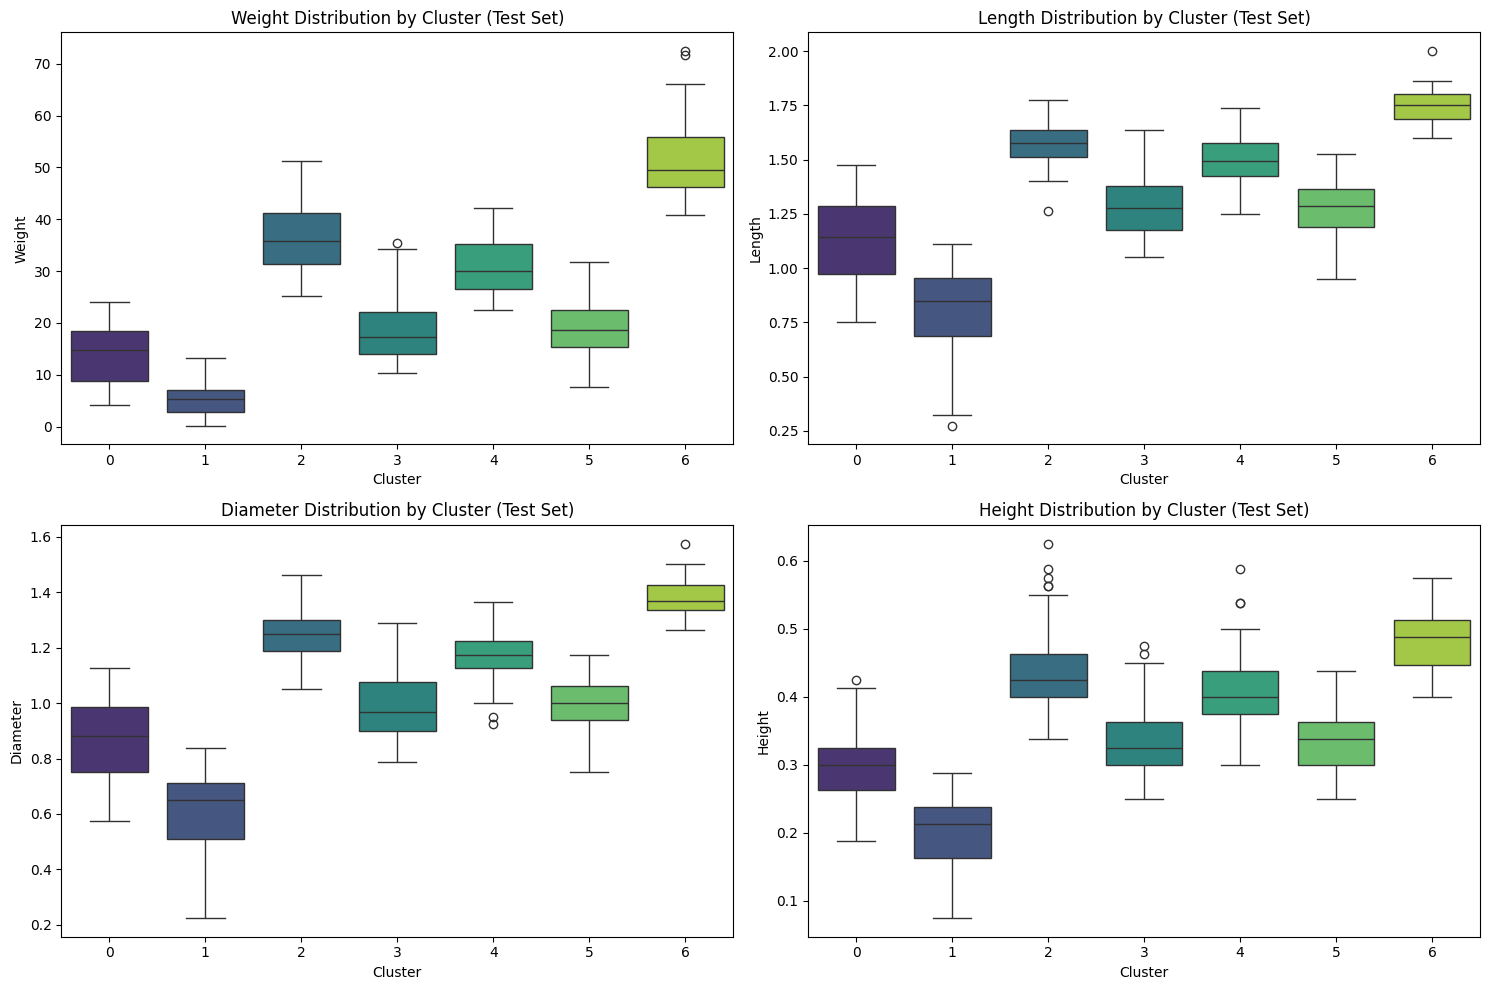

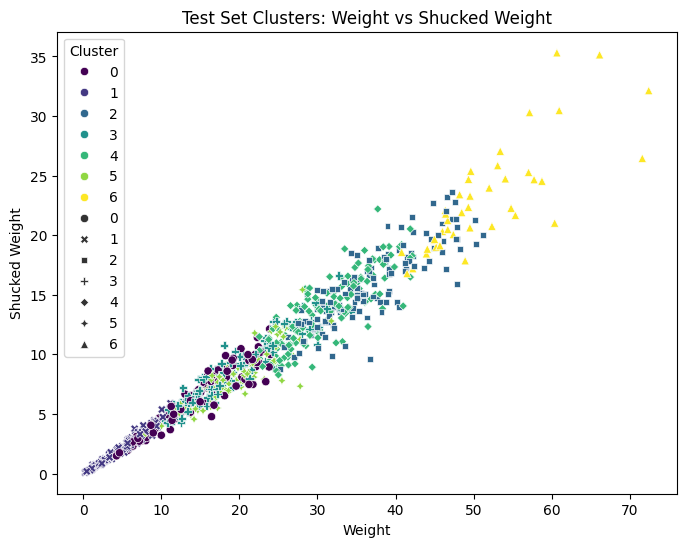

In [ ]:
# 7. Easy Visualization: Feature Distribution by Cluster
cols_to_plot = ['Weight', 'Length', 'Diameter', 'Height']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Cluster', y=col, data=X_test_with_clusters, palette='viridis')
    plt.title(f'{col} Distribution by Cluster (Test Set)')

plt.tight_layout()
plt.show()

# Scatter plot of two highly correlated physical features
plt.figure(figsize=(8, 6))
sns.scatterplot(data=X_test_with_clusters, x='Weight', y='Shucked Weight', 
                hue='Cluster', palette='viridis', style='Cluster')
plt.title('Test Set Clusters: Weight vs Shucked Weight')
plt.show()

visualisation on train data

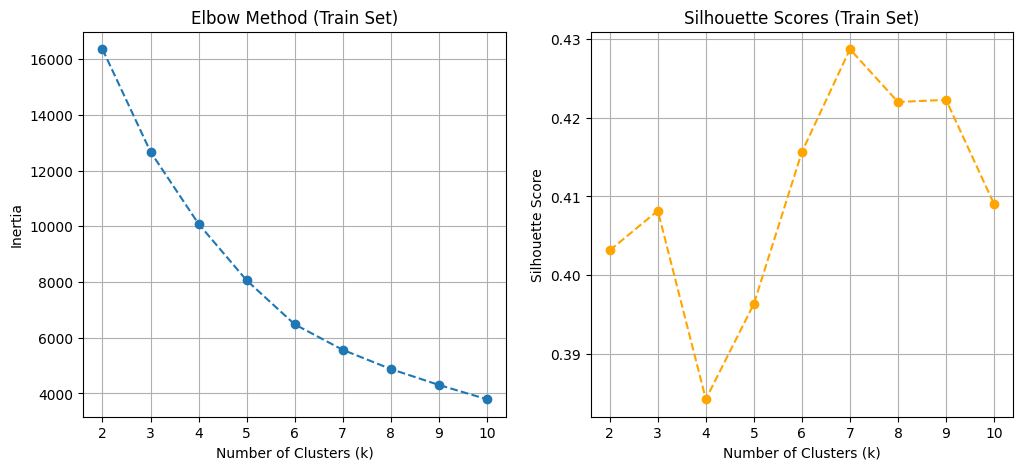

Optimal clusters for Training Data: 7


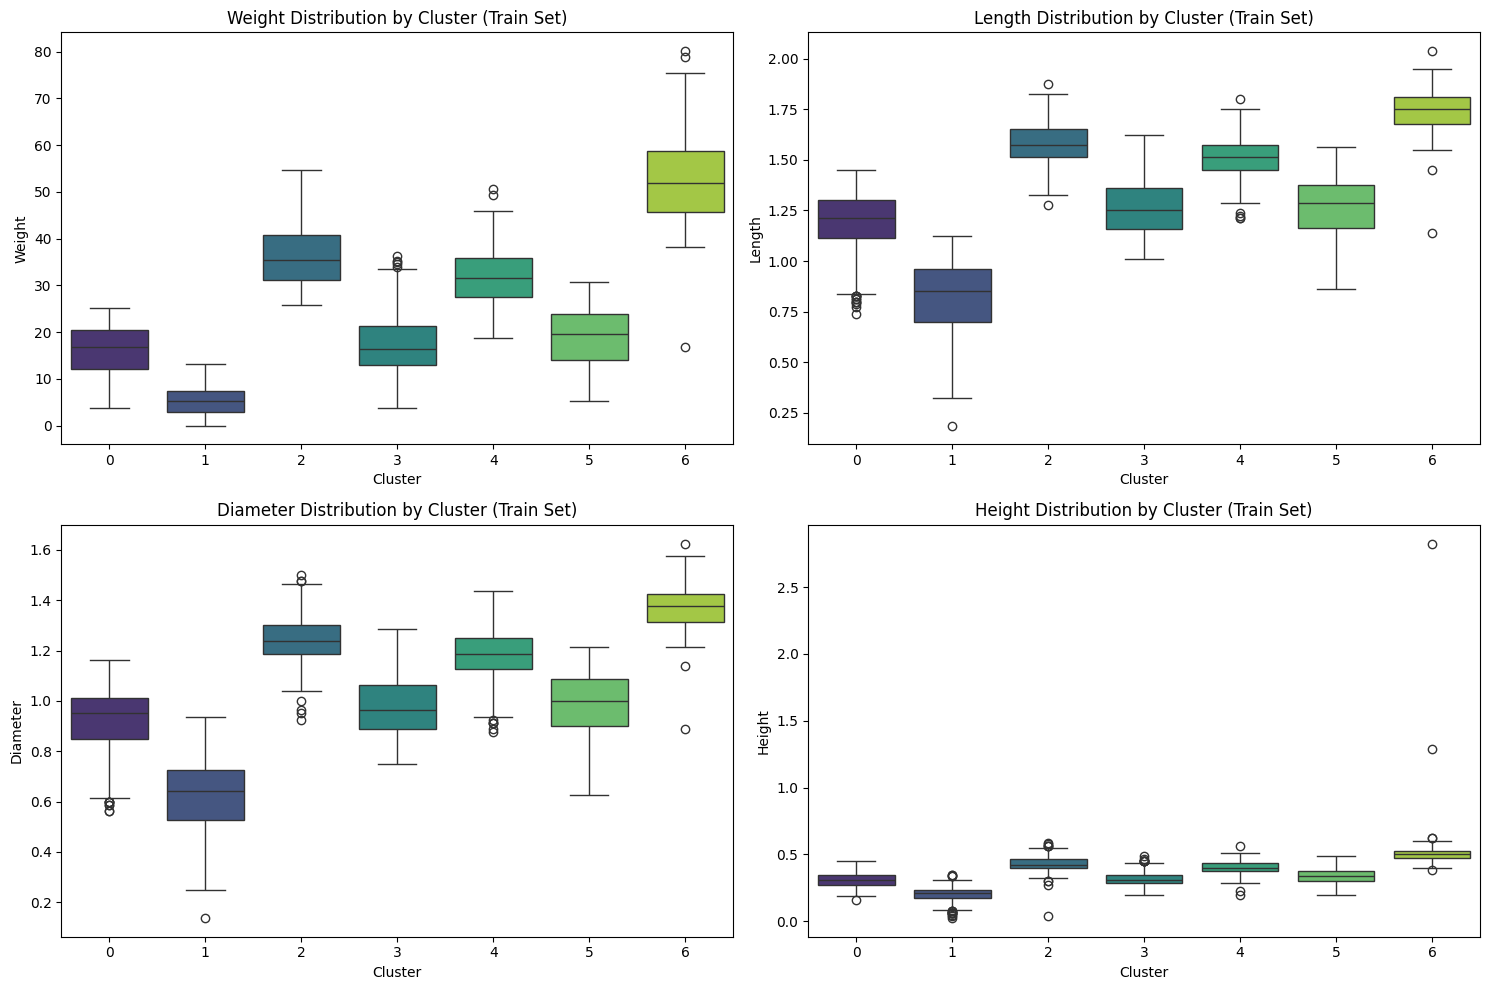

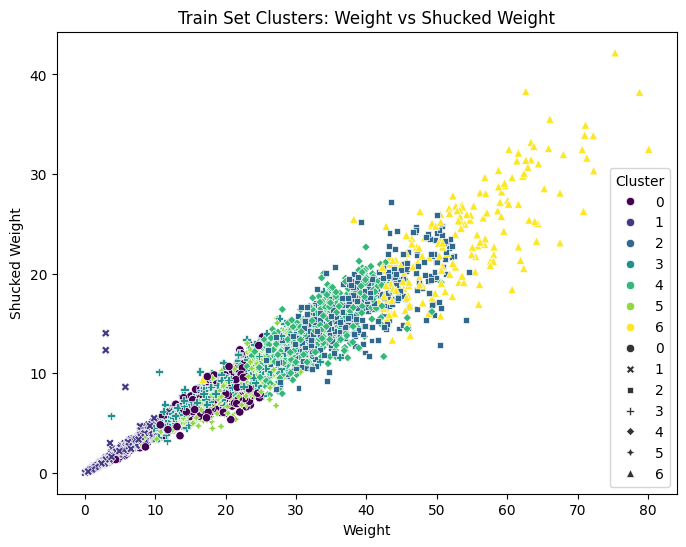

In [ ]:
# Plotting Elbow and Silhouette for the Training Set
plt.figure(figsize=(12, 5))

# Elbow Plot
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method (Train Set)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Silhouette Score Plot
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o', linestyle='--', color='orange')
plt.title('Silhouette Scores (Train Set)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Automatically select the optimal K (highest silhouette score)
optimal_k = k_range[sil_scores.index(max(sil_scores))]
print(f"Optimal clusters for Training Data: {optimal_k}")

# 6. Final Clustering and Visualization on the Training Set
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
train_clusters = final_kmeans.fit_predict(X_train_scaled)

# Add clusters back to the original (unscaled) training features for plotting
X_train_with_clusters = X_train.copy()
X_train_with_clusters['Cluster'] = train_clusters
# Add clusters back to the original (unscaled) training features for plotting
X_train_with_clusters = X_train.copy()
X_train_with_clusters['Cluster'] = train_clusters

# Visualisation A: Feature Distributions (No PCA)
cols_to_plot = ['Weight', 'Length', 'Diameter', 'Height']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Cluster', y=col, data=X_train_with_clusters, palette='viridis')
    plt.title(f'{col} Distribution by Cluster (Train Set)')

plt.tight_layout()
plt.show()

# Visualisation B: Physical Growth Scatter Plot (Correlated features)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=X_train_with_clusters, x='Weight', y='Shucked Weight',
                hue='Cluster', palette='viridis', style='Cluster')
plt.title('Train Set Clusters: Weight vs Shucked Weight')
plt.show()